# MLP Classifier - Stellar Classification

## Load, Split, Balance Data

In [19]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sympy.assumptions.sathandlers import class_fact_registry

pd.set_option("display.max_columns", None)

df = pd.read_csv("./star_classification.csv")

features = ["u", "g", "r", "i", "z", "redshift"]

drop_cols = ["obj_ID", "alpha", "delta", "run_ID", "rerun_ID", "cam_col", "field_ID", "spec_obj_ID", "plate", "MJD", "fiber_ID"]
df.drop(columns=drop_cols, inplace=True)

duplicates = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

X = df[features]
y = df["class"]

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, stratify=y_encoded, random_state=42
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

undersampler = RandomUnderSampler(random_state=42)

X_train_balanced, y_train_balanced = undersampler.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled  = scaler.transform(X_test)

print("Class encoding:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
print("Train / validation / test rows:", len(X_train), len(X_validation), len(X_test))
print("\nBalanced training counts:")
print(pd.Series(y_train_balanced).value_counts().sort_index())

Class encoding: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}
Train / validation / test rows: 70000 15000 15000

Balanced training counts:
0    13273
1    13273
2    13273
Name: count, dtype: int64


## Comparing MLP Model Sizes

In [20]:
architectures = [
    (32,),
    (64,),
    (128,),
    (64, 32),
    (128, 64),
    (256, 128),
    (64, 64),
    (128, 128),
    (128, 64, 32),
]
highest_accuracy = 0
best_architecture = None
for architecture in architectures:
    mlp = MLPClassifier(hidden_layer_sizes=architecture, activation='relu', max_iter=500, random_state=42)
    mlp.fit(X_train_scaled, y_train_balanced)
    mlp_training_accuracy = accuracy_score(y_train_balanced, mlp.predict(X_train_scaled))
    y_predict = mlp.predict(X_validation_scaled)
    mlp_validation_accuracy = accuracy_score(y_validation, y_predict)
    if mlp_validation_accuracy > highest_accuracy:
        highest_accuracy = mlp_validation_accuracy
        best_architecture = architecture


    print("MLP Architecture:", architecture)
    print("Training accuracy:", mlp_training_accuracy)
    print("Validation accuracy:", mlp_validation_accuracy)
    # print(classification_report(y_validation, y_predict))
    print()
print("Best architecture:", best_architecture)
print("Validation accuracy:", highest_accuracy)

MLP Architecture: (32,)
Training accuracy: 0.9683568145860016
Validation accuracy: 0.9646666666666667

MLP Architecture: (64,)
Training accuracy: 0.9688842010095683
Validation accuracy: 0.9611333333333333

MLP Architecture: (128,)
Training accuracy: 0.9694869283507873
Validation accuracy: 0.9673333333333334

MLP Architecture: (64, 32)
Training accuracy: 0.9698385192998318
Validation accuracy: 0.9645333333333334

MLP Architecture: (128, 64)
Training accuracy: 0.9704914739194856
Validation accuracy: 0.9706

MLP Architecture: (256, 128)
Training accuracy: 0.9607976091815466
Validation accuracy: 0.9609333333333333

MLP Architecture: (64, 64)
Training accuracy: 0.9710188603430523
Validation accuracy: 0.9664666666666667

MLP Architecture: (128, 128)
Training accuracy: 0.971169542178357
Validation accuracy: 0.9677333333333333

MLP Architecture: (128, 64, 32)
Training accuracy: 0.9696376101860921
Validation accuracy: 0.9668666666666667

Best architecture: (128, 64)
Validation accuracy: 0.9706


## Comparing MLP Model Activation Functions

In [21]:
activation_functions = [
    'relu',
    'tanh',
    'logistic'
]
mlp_validation_accuracy = 0
best_function = None
highest_accuracy = 0
for activation_function in activation_functions:
    mlp = MLPClassifier(hidden_layer_sizes=best_architecture, activation=activation_function, max_iter=500, random_state=42)
    mlp.fit(X_train_scaled, y_train_balanced)
    mlp_training_accuracy = accuracy_score(y_train_balanced, mlp.predict(X_train_scaled))
    y_predict = mlp.predict(X_validation_scaled)
    mlp_validation_accuracy = accuracy_score(y_validation, y_predict)

    print("MLP Activation Function:", activation_function)
    print("Training accuracy:", mlp_training_accuracy)
    print("Validation accuracy:", mlp_validation_accuracy)

    if mlp_validation_accuracy > highest_accuracy:
        highest_accuracy = mlp_validation_accuracy
        best_function = activation_function
print("Best activation function:", best_function)
print("Validation accuracy:", highest_accuracy)

MLP Activation Function: relu
Training accuracy: 0.9704914739194856
Validation accuracy: 0.9706
MLP Activation Function: tanh
Training accuracy: 0.971219769456792
Validation accuracy: 0.9698
MLP Activation Function: logistic
Training accuracy: 0.96787965544087
Validation accuracy: 0.9652
Best activation function: relu
Validation accuracy: 0.9706


## Comparing MLP Learning Rate and Alphas

In [22]:
import numpy as np
pipeline = Pipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("scale", StandardScaler()),
    ("mlp", MLPClassifier(
        early_stopping=True,
        max_iter=500,
        random_state=42
    ))
])

hyperparameters = {
    "mlp__hidden_layer_sizes": [best_architecture],
    "mlp__alpha": [1e-4, 1e-3, 1e-2],
    "mlp__learning_rate_init": [1e-4, 1e-3, 1e-2],
}

grid = GridSearchCV(estimator=pipeline, param_grid=hyperparameters, cv=5, n_jobs=-1,verbose=3)
grid.fit(np.concat([X_train, X_validation], axis=0), np.concat([y_train, y_validation], axis=0))

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 2/5] END mlp__alpha=0.0001, mlp__hidden_layer_sizes=(128, 64), mlp__learning_rate_init=0.001;, score=0.960 total time=   2.1s
[CV 3/5] END mlp__alpha=0.0001, mlp__hidden_layer_sizes=(128, 64), mlp__learning_rate_init=0.001;, score=0.966 total time=   2.6s
[CV 5/5] END mlp__alpha=0.0001, mlp__hidden_layer_sizes=(128, 64), mlp__learning_rate_init=0.001;, score=0.966 total time=   2.6s
[CV 4/5] END mlp__alpha=0.0001, mlp__hidden_layer_sizes=(128, 64), mlp__learning_rate_init=0.001;, score=0.964 total time=   3.8s
[CV 3/5] END mlp__alpha=0.0001, mlp__hidden_layer_sizes=(128, 64), mlp__learning_rate_init=0.01;, score=0.962 total time=   2.0s
[CV 1/5] END mlp__alpha=0.0001, mlp__hidden_layer_sizes=(128, 64), mlp__learning_rate_init=0.0001;, score=0.957 total time=   4.9s
[CV 2/5] END mlp__alpha=0.0001, mlp__hidden_layer_sizes=(128, 64), mlp__learning_rate_init=0.0001;, score=0.955 total time=   4.9s
[CV 1/5] END mlp__alpha=0.000

## Best Model Training

In [23]:
best_alpha = grid.best_params_["mlp__alpha"]
best_learning_rate_init = grid.best_params_["mlp__learning_rate_init"]
best_mlp = MLPClassifier(hidden_layer_sizes=best_architecture, activation=best_function, alpha=best_alpha, learning_rate_init=best_learning_rate_init, max_iter=500, random_state=42)
train_predictions = best_mlp.fit(X_train_scaled, y_train_balanced)
print("Model Parameters")
print("Architecture:", best_architecture)
print("Activation function:", best_function)
print("Alpha:", best_alpha)
print("Learning rate:", best_learning_rate_init)
print("Loss Function: Cross Entropy Loss")
print("Solver:", best_mlp.solver)
print("Batch Size: ", best_mlp.batch_size)


Model Parameters
Architecture: (128, 64)
Activation function: relu
Alpha: 0.0001
Learning rate: 0.001
Loss Function: Cross Entropy Loss
Solver: adam
Batch Size:  auto


## Model Report

In [24]:
import matplotlib.pyplot as plt
validation_predictions = best_mlp.predict(X_validation_scaled)
validation_report = classification_report(validation_predictions, y_validation, target_names=encoder.classes_)
print(validation_report)

              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98      8882
         QSO       0.93      0.94      0.94      2810
        STAR       1.00      0.98      0.99      3308

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



Multi-layer Perceptron Classification Report
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98      8825
         QSO       0.94      0.94      0.94      2860
        STAR       1.00      0.97      0.99      3315

    accuracy                           0.97     15000
   macro avg       0.97      0.96      0.97     15000
weighted avg       0.97      0.97      0.97     15000



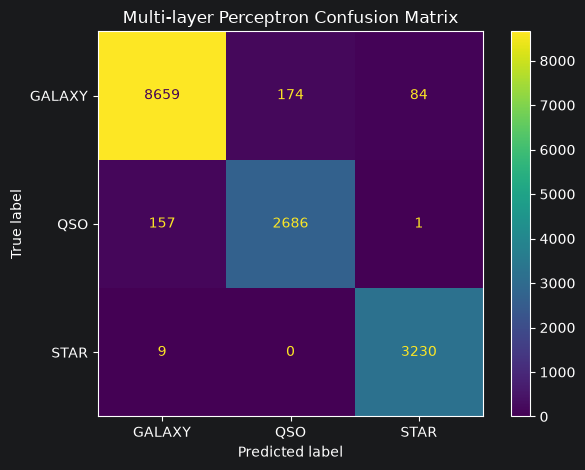

In [25]:
test_predictions = best_mlp.predict(X_test_scaled)
test_report = classification_report(test_predictions, y_test, target_names=encoder.classes_)
print("Multi-layer Perceptron Classification Report")
print(test_report)
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, display_labels=encoder.classes_)
plt.title("Multi-layer Perceptron Confusion Matrix")
plt.tight_layout()
plt.savefig("./Model_Charts/mlp_confusion_matrix.png")
